# ML: Non-Linear Regression — Polynomial / Quadratic

When a relationship between two variables looks like a parabola — going down then up, or up then down — a quadratic (degree-2 polynomial) regression captures it cleanly.

## Theory
- https://mlu-explain.github.io/linear-regression/
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

## Equation
`y = a · x² + b · x + c`

The trick: `PolynomialFeatures(degree=2)` augments the input matrix with `x²`, so the same `LinearRegression` solver returns the polynomial coefficients.

## Problem Statement — house age vs price

Brand-new builds sell at a premium for modern features. Mid-age homes (15–30 yr) dip in price as initial finishes date and there's no heritage value yet. Old homes (50–100 yr) recover as historic / character properties on bigger lots. The result is a U-shape that a parabola fits well.

| age (yr) | price ($k) |
| :------: | :--------: |
| 1   | 780 |
| 5   | 690 |
| 10  | 600 |
| 15  | 540 |
| 20  | 510 |
| 25  | 500 |
| 30  | 510 |
| 40  | 560 |
| 55  | 660 |
| 70  | 770 |
| 85  | 880 |
| 100 | 990 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

%matplotlib inline

In [2]:
data = {
    'age':   [1, 5, 10, 15, 20, 25, 30, 40, 55, 70, 85, 100],
    'price': [780, 690, 600, 540, 510, 500, 510, 560, 660, 770, 880, 990],
}
test = {'age': [3, 22, 45, 90]}

df = pd.DataFrame(data)
df

,age,price
0,1,780
1,5,690
2,10,600
3,15,540
4,20,510
5,25,500
6,30,510
7,40,560
8,55,660
9,70,770


Text(0.5, 1.0, 'U-shape: new + heritage homes priced higher than mid-age')

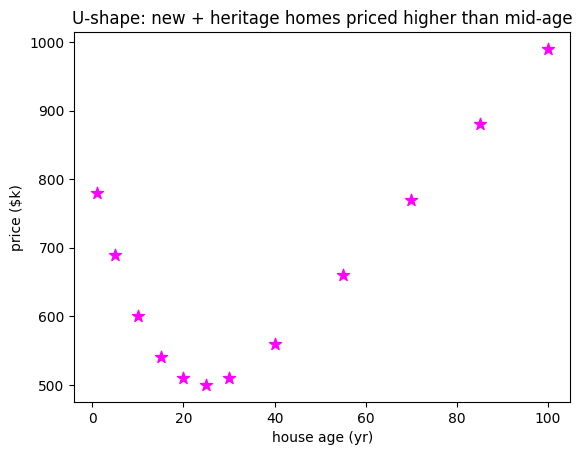

In [3]:
plt.scatter(df.age, df.price, color='magenta', marker='*', s=80)
plt.xlabel('house age (yr)')
plt.ylabel('price ($k)')
plt.title('U-shape: new + heritage homes priced higher than mid-age')

Fit a degree-2 polynomial — `PolynomialFeatures` builds `[age, age²]` columns, then plain linear regression solves for the coefficients.

In [4]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X = poly.fit_transform(df[['age']].values)
reg = LinearRegression().fit(X, df['price'])

# PolynomialFeatures returns columns in order [x, x^2]
b, a = reg.coef_
c = reg.intercept_
print(f'fit: price = {a:.4f} * age^2 + {b:.4f} * age + {c:.4f}')

fit: price = 0.1186 * age^2 + -8.2133 * age + 691.0055


In [5]:
tst = pd.DataFrame(test)
tst['price'] = reg.predict(poly.transform(tst[['age']].values))
tst

,age,price
0,3,667.433216
1,22,567.727138
2,45,561.621808
3,90,912.668306


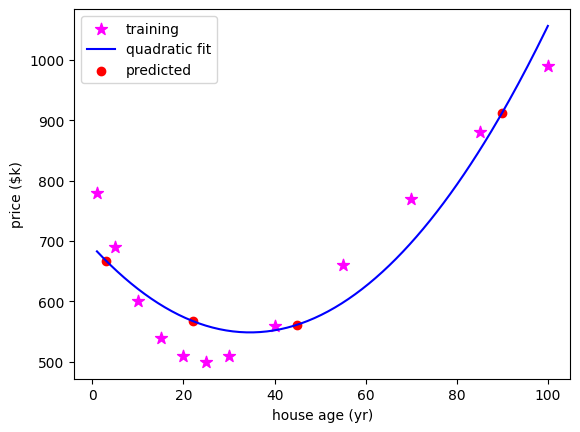

In [6]:
age_grid = np.linspace(df.age.min(), df.age.max(), 200)
curve = reg.predict(poly.transform(age_grid.reshape(-1, 1)))

plt.scatter(df.age, df.price, color='magenta', marker='*', s=80, label='training')
plt.plot(age_grid, curve, color='blue', label='quadratic fit')
plt.scatter(tst.age, tst.price, color='red', label='predicted')
plt.xlabel('house age (yr)')
plt.ylabel('price ($k)')
plt.legend()